<h1><strong>Decision Tree Stock Market Classification (Analysing Buy and Sell Signal)</strong></h1>

In [88]:
import pandas_datareader.data as web
import numpy as np
import datetime
import yfinance as yf
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
start = datetime.datetime(2010,1,1)
end = datetime.datetime.now()

In [90]:
df = yf.download('META', start=start, end=end)
df.head(30)

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-05-18,42.049999,45.000000,38.000000,38.230000,38.115238,573576400
2012-05-21,36.529999,36.660000,33.000000,34.029999,33.927845,168192700
2012-05-22,32.610001,33.590000,30.940001,31.000000,30.906942,101786600
2012-05-23,31.370001,32.500000,31.360001,32.000000,31.903942,73600000
2012-05-24,32.950001,33.209999,31.770000,33.029999,32.930851,50237200
2012-05-25,32.900002,32.950001,31.110001,31.910000,31.814211,37149800
2012-05-29,31.480000,31.690001,28.650000,28.840000,28.753428,78063400
2012-05-30,28.700001,29.549999,27.860001,28.190001,28.105379,57267900
2012-05-31,28.549999,29.670000,26.830000,29.600000,29.511147,111639200


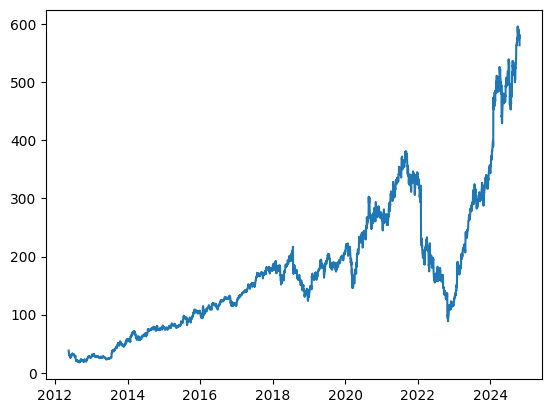

In [91]:
plt.plot(df['Adj Close'])

In [92]:
df['Returns'] = df ['Adj Close'].pct_change(60).shift(-60)
list_of_feture = ['High', 'Low', 'Close', 'Volume', 'Adj Close']
X = df[list_of_feture]
y = np.where(df['Returns'] > 0, 1, 0)

In [93]:
df.head(20)

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2012-05-18,42.049999,45.000000,38.000000,38.230000,38.115238,573576400,-0.466911
2012-05-21,36.529999,36.660000,33.000000,34.029999,33.927845,168192700,-0.377020
2012-05-22,32.610001,33.590000,30.940001,31.000000,30.906942,101786600,-0.359032
2012-05-23,31.370001,32.500000,31.360001,32.000000,31.903942,73600000,-0.404688
2012-05-24,32.950001,33.209999,31.770000,33.029999,32.930851,50237200,-0.394187
2012-05-25,32.900002,32.950001,31.110001,31.910000,31.814211,37149800,-0.399561
2012-05-29,31.480000,31.690001,28.650000,28.840000,28.753428,78063400,-0.325936
2012-05-30,28.700001,29.549999,27.860001,28.190001,28.105379,57267900,-0.310394
2012-05-31,28.549999,29.670000,26.830000,29.600000,29.511147,111639200,-0.344257


In [94]:
y[0:70]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1])

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print("X train shape:", X_train.shape)
print("Y train shape:", y_train.shape)
print("X test shape:", X_test.shape)
print("Y test shape:", y_test.shape)

X train shape: (2189, 5)
Y train shape: (2189,)
X test shape: (939, 5)
Y test shape: (939,)


In [96]:
tree_classifier = DecisionTreeClassifier(max_depth=3, min_samples_leaf=6)
tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=6)

In [97]:
y_prediction = tree_classifier.predict(X_test)

In [98]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.18      0.30       333
           1       0.69      0.98      0.81       606

    accuracy                           0.70       939
   macro avg       0.75      0.58      0.55       939
weighted avg       0.73      0.70      0.63       939



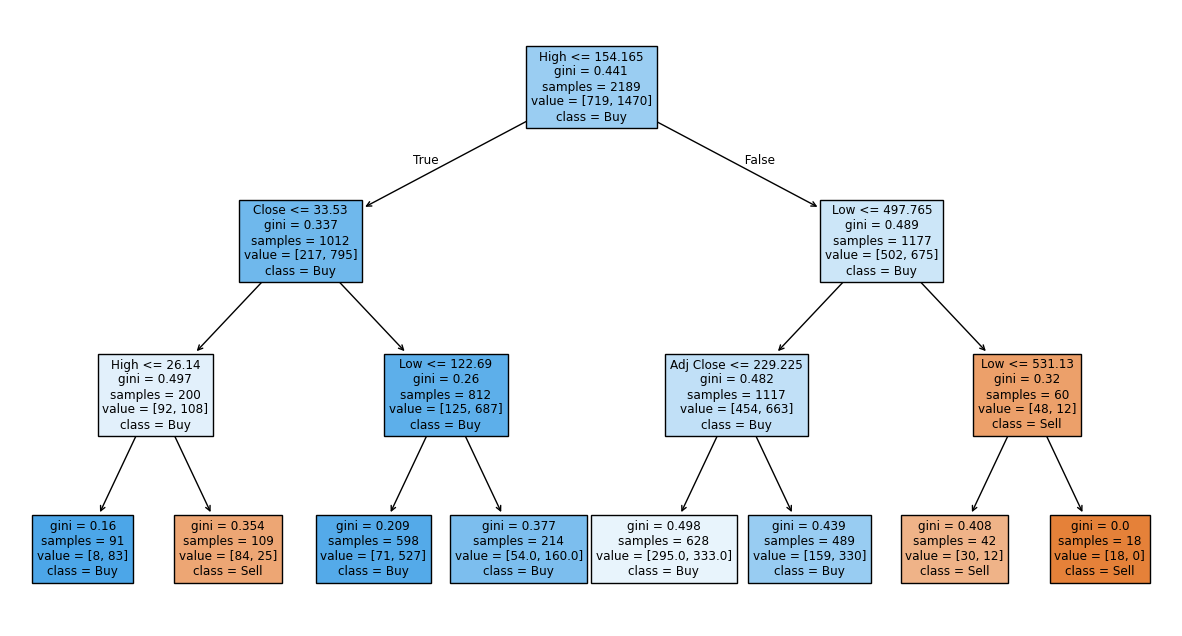

In [100]:
from sklearn import tree

plt.figure(figsize=(15, 8))
tree.plot_tree(tree_classifier, filled=True, feature_names=list_of_feture, class_names=['Sell', 'Buy'])
plt.show()